 Hybrid Integration Model

This notebook is the final integration stage of the project. In the earlier notebooks, the behavioral branch and the text-mining branch were developed separately. Here, I combine both branches into one review-level modeling pipeline.

The main purpose of this notebook is to test whether combining behavioral features and text-derived features improves predictive performance compared with using either branch on its own.

 Our Main goals:
- Load the behavioral review-level dataset
- Load the exported text-feature dataset
- Merge both datasets safely at review level
- Build three modeling setups:
  - behavioral-only
  - text-only
  - combined / hybrid
- Train multiple classifiers and compare their performance
- Interpret which features contribute most strongly to the final hybrid model

Load the Behavioral and Text Branch Outputs

I begin by importing the libraries needed for data handling, visualization, and file access. Since this notebook is being run locally in VS Code rather than in Google Colab, I set the base path to the local Windows Downloads directory and load the two parquet files directly from there.

The two files loaded in this step are:

- `steam_reviews_sampled.parquet` from the behavioral branch
- `steam_text_features_export.parquet` from the text mining branch

I also verify that both file paths exist before reading them. This helps confirm that the notebook is correctly connected to the local copies of the project outputs and avoids path-related errors before moving to the hybrid merge stage.

At the end of this step, I confirm the number of rows and columns in both datasets so I can check that the expected branch outputs were loaded successfully.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE = r'C:\Users\Fareed Durgam\Downloads\\'

behavior_path = BASE + 'steam_reviews_sampled.parquet'
text_path = BASE + 'steam_text_features_export.parquet'

print("Behavioral path:", behavior_path)
print("Text path:", text_path)
print("Behavioral exists:", os.path.exists(behavior_path))
print("Text exists:", os.path.exists(text_path))

print("\nLoading behavioral data...")
df_behavioral = pd.read_parquet(behavior_path)
print(f"Behavioral : {len(df_behavioral):,} rows, {df_behavioral.shape[1]} columns")

print("\nLoading text features...")
df_text = pd.read_parquet(text_path)
print(f"Text       : {len(df_text):,} rows, {df_text.shape[1]} columns")

print("\nBoth files loaded successfully")

Behavioral path: C:\Users\Fareed Durgam\Downloads\\steam_reviews_sampled.parquet
Text path: C:\Users\Fareed Durgam\Downloads\\steam_text_features_export.parquet
Behavioral exists: True
Text exists: True

Loading behavioral data...
Behavioral : 2,609,677 rows, 23 columns

Loading text features...
Text       : 919,083 rows, 15 columns

Both files loaded successfully


 Inspect the Behavioral and Text Datasets:

Before merging the two branches, I first inspect the shape, columns, and data types of both files. This helps confirm that the expected review-level identifiers, target variables, and engineered text features are present.

This step is especially important because the hybrid model depends on a clean alignment between the behavioral review rows and the text-feature export.

In [2]:
# Checking behavioral file
print("=" * 50)
print("BEHAVIORAL FILE")
print("=" * 50)
print(f"Shape   : {df_behavioral.shape}")
print(f"Columns : {df_behavioral.columns.tolist()}")
print(f"\nData types:")
print(df_behavioral.dtypes)

print("\n")

# Checking text file
print("=" * 50)
print("TEXT FEATURES FILE")
print("=" * 50)
print(f"Shape   : {df_text.shape}")
print(f"Columns : {df_text.columns.tolist()}")
print(f"\nData types:")
print(df_text.dtypes)

BEHAVIORAL FILE
Shape   : (2609677, 23)
Columns : ['Unnamed: 0', 'app_id', 'app_name', 'review_id', 'language', 'review', 'timestamp_created', 'timestamp_updated', 'recommended', 'votes_helpful', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'author.steamid', 'author.num_games_owned', 'author.num_reviews', 'author.playtime_forever', 'author.playtime_last_two_weeks', 'author.playtime_at_review', 'author.last_played']

Data types:
Unnamed: 0                          int64
app_id                              int64
app_name                           object
review_id                           int64
language                           object
review                             object
timestamp_created                   int64
timestamp_updated                   int64
recommended                          bool
votes_helpful                       int64
votes_funny                         int64
weighted_vote_score       

 Sanity Check for Game Coverage:

Before merging at review level, I compare the unique `app_id` values in both datasets. This acts as a quick consistency check to confirm that the behavioral and text branches cover the same set of games.

Since both files contain 315 unique games and all 315 overlap, this suggests that the two branch outputs are aligned at the game level before I move to the review-level merge.

In [3]:
print("Behavioral unique app_ids:", df_behavioral['app_id'].nunique())
print("Text unique app_ids      :", df_text['app_id'].nunique())

common_apps = set(df_behavioral['app_id'].unique()) & set(df_text['app_id'].unique())
print(f"Common app_ids           : {len(common_apps)}")

Behavioral unique app_ids: 315
Text unique app_ids      : 315
Common app_ids           : 315


 Validate the Review-Level Merge Key:

The hybrid model must be built at **review level**, not game level. Because of that, the most important identifier is `review_id`.

In this section, I check that:
- `review_id` exists in both files
- the number of unique review IDs is reasonable
- the overlap between both datasets is sufficient for a valid merge

This is one of the most important structural checks in the notebook, because the entire hybrid setup depends on the correctness of this merge.

In [4]:
print("=" * 60)
print("MERGE KEY CHECK")
print("=" * 60)

print("review_id in behavioral:", 'review_id' in df_behavioral.columns)
print("review_id in text      :", 'review_id' in df_text.columns)

if 'review_id' in df_behavioral.columns and 'review_id' in df_text.columns:
    print("\nBehavioral unique review_ids:", df_behavioral['review_id'].nunique())
    print("Text unique review_ids      :", df_text['review_id'].nunique())

    common_reviews = set(df_behavioral['review_id'].unique()) & set(df_text['review_id'].unique())
    print("Common review_ids           :", len(common_reviews))
else:
    print("\nERROR: review_id not found in one of the files")

MERGE KEY CHECK
review_id in behavioral: True
review_id in text      : True

Behavioral unique review_ids: 2607599
Text unique review_ids      : 918399
Common review_ids           : 918399


Identify Overlapping Columns Between Both Branches:

Before merging the behavioral and text datasets, I inspect the columns that appear in both files. This helps me understand which variables are shared across the two branches and which duplicated columns should be handled carefully before the final review-level merge.

From this check, I can see that both datasets share:
- `app_id`
- `app_name`
- `recommended`
- `review_id`
- `votes_helpful`

Among these, `review_id` is the key variable needed for the hybrid merge, while the other overlapping columns are reviewed so that duplicate versions are not carried unnecessarily into the merged dataset.

In [5]:
common_cols = sorted(set(df_behavioral.columns).intersection(set(df_text.columns)))
print("Common columns:")
print(common_cols)

Common columns:
['app_id', 'app_name', 'recommended', 'review_id', 'votes_helpful']


Build the Review-Level Hybrid Dataset:

In this step, I construct the main hybrid table used throughout the rest of the notebook.

First, I keep only the behavioral columns that are relevant for the final model, such as:
- purchase status
- early-access participation
- reviewer history
- playtime at review
- helpfulness count

Then, from the text-feature dataset, I remove duplicated columns that already exist in the behavioral subset. This keeps the merged table cleaner and avoids carrying duplicate versions of the same variables.

Finally, I merge both subsets using an **inner join on `review_id`**. This ensures that every row in the final hybrid dataset represents a single review for which I have:
- behavioral information, and
- engineered text features

The resulting merged table is the core review-level dataset used for all later cleaning, feature construction, and modeling steps.

In [6]:
# Keep needed behavioral columns
behavior_cols = [
    'review_id',
    'app_id',
    'app_name',
    'recommended',
    'steam_purchase',
    'received_for_free',
    'written_during_early_access',
    'author.num_games_owned',
    'author.num_reviews',
    'author.playtime_at_review',
    'votes_helpful'
]

df_behavioral_sub = df_behavioral[behavior_cols].copy()

# Drop duplicated columns from text before merge
drop_from_text = ['app_id', 'app_name', 'recommended', 'votes_helpful']
drop_from_text = [c for c in drop_from_text if c in df_text.columns]

df_text_sub = df_text.drop(columns=drop_from_text).copy()

# Merge
df_hybrid = df_behavioral_sub.merge(
    df_text_sub,
    on='review_id',
    how='inner'
)

print("Hybrid shape:", df_hybrid.shape)
print(df_hybrid.columns.tolist())

Hybrid shape: (920451, 21)
['review_id', 'app_id', 'app_name', 'recommended', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'author.num_games_owned', 'author.num_reviews', 'author.playtime_at_review', 'votes_helpful', 'review_cleaned_sentiment', 'polarity', 'subjectivity', 'word_count_cleaned', 'ttr', 'lda_topic', 'lda_topic_label', 'nmf_topic', 'nmf_topic_label', 'is_helpful']


 Prepare the Text Feature Subset:

In this step, I refine the text-feature dataset before merging it with the behavioral subset. Since some columns such as `recommended`, `app_name`, `app_id`, and `votes_helpful` already exist in the behavioral data, I remove them from the text side to avoid duplicate columns after the merge.

After dropping those overlapping fields, the remaining text subset contains the engineered review-level text features created in the earlier text-mining notebooks, including:
- cleaned review text
- sentiment polarity
- sentiment subjectivity
- review length
- vocabulary richness
- topic assignments and topic labels
- helpfulness indicator

This gives me a clean text-feature table that is ready to be merged with the behavioral subset using `review_id`.

In [7]:
drop_from_text = [
    'recommended',
    'app_name',
    'app_id',
    'votes_helpful'
]

drop_from_text = [col for col in drop_from_text if col in df_text.columns]

df_text_sub = df_text.drop(columns=drop_from_text).copy()

print("Text subset shape:", df_text_sub.shape)
print(df_text_sub.columns.tolist())

Text subset shape: (919083, 11)
['review_id', 'review_cleaned_sentiment', 'polarity', 'subjectivity', 'word_count_cleaned', 'ttr', 'lda_topic', 'lda_topic_label', 'nmf_topic', 'nmf_topic_label', 'is_helpful']


Preview the Merged Hybrid Dataset:

After preparing the behavioral and text subsets separately, I now merge them at **review level** using `review_id`. I use an inner join so that only reviews present in both branches are kept in the final hybrid dataset.

In this step, I check:
- the overall shape of the merged table
- the number of unique review IDs retained after merging
- a preview of the first few rows

This gives me a quick confirmation that the merge worked correctly and that the final dataset now contains both:
- behavioral review-level variables, and
- engineered text-derived features

The merged dataset produced here becomes the main working table for all later cleaning, feature engineering, and model training steps.

In [8]:
df_hybrid = df_behavioral_sub.merge(
    df_text_sub,
    on='review_id',
    how='inner'
)

print("=" * 60)
print("MERGED HYBRID DATA")
print("=" * 60)
print("Shape:", df_hybrid.shape)
print("Unique review_ids:", df_hybrid['review_id'].nunique())
print(df_hybrid.head())

MERGED HYBRID DATA
Shape: (920451, 21)
Unique review_ids: 918399
   review_id  app_id   app_name  recommended  steam_purchase  \
0   76039982      70  Half-Life         True            True   
1   54706129      70  Half-Life         True            True   
2   62350493      70  Half-Life         True           False   
3   78781414      70  Half-Life         True            True   
4   72234963      70  Half-Life         True            True   

   received_for_free  written_during_early_access  author.num_games_owned  \
0              False                        False                      23   
1              False                        False                     208   
2               True                        False                      24   
3              False                        False                      18   
4              False                        False                      73   

   author.num_reviews  author.playtime_at_review  ...  \
0                   3         

Clean the Behavioral Variables and Engineer Playtime Features:

Before training the hybrid model, I apply a focused behavioral cleaning step to the merged review-level dataset.

From the earlier behavioral notebooks, I already knew that some reviewer-history variables could contain extreme or corrupted values. In particular, I check `author.num_games_owned` for unrealistic outliers and remove any clearly invalid values above the chosen threshold.

I also drop rows that are missing key behavioral fields needed for the final model:
- `author.playtime_at_review`
- `author.num_games_owned`
- `author.num_reviews`

After that, I engineer two playtime-based features:
- `playtime_hours`
- `log_playtime_hours`

This is important because playtime is highly skewed, and the log-transformed version helps capture the same signal in a more stable way for modeling. Finally, I inspect the shape of the cleaned dataset and summarize the main behavioral variables to confirm that the cleaning step worked as expected.

In [9]:
print("=" * 60)
print("BEHAVIORAL CLEANING")
print("=" * 60)

# Remove known corrupted outlier(s) in games owned
if 'author.num_games_owned' in df_hybrid.columns:
    print("Rows with author.num_games_owned > 25000:",
          (df_hybrid['author.num_games_owned'] > 25000).sum())
    df_hybrid = df_hybrid[df_hybrid['author.num_games_owned'] <= 25000].copy()

# Drop rows missing important behavioral fields
required_behavior_cols = [
    'author.playtime_at_review',
    'author.num_games_owned',
    'author.num_reviews'
]
required_behavior_cols = [c for c in required_behavior_cols if c in df_hybrid.columns]

df_hybrid = df_hybrid.dropna(subset=required_behavior_cols).copy()

# Playtime features
df_hybrid['playtime_hours'] = df_hybrid['author.playtime_at_review'] / 60
df_hybrid['log_playtime_hours'] = np.log1p(df_hybrid['playtime_hours'])

print("Shape after cleaning:", df_hybrid.shape)
print(df_hybrid[['author.num_games_owned', 'author.num_reviews', 'playtime_hours']].describe())

BEHAVIORAL CLEANING
Rows with author.num_games_owned > 25000: 1
Shape after cleaning: (919210, 23)
       author.num_games_owned  author.num_reviews  playtime_hours
count           919210.000000       919210.000000   919210.000000
mean               183.649063           12.728206      150.570403
std                334.578166           35.427984      439.235502
min                  0.000000            1.000000        0.016667
25%                 38.000000            2.000000        9.900000
50%                 97.000000            5.000000       32.233333
75%                213.000000           12.000000      114.100000
max              22019.000000         3473.000000    34530.133333


 Use the Full Cleaned Hybrid Dataset:

At this stage, I decide whether to continue with a sampled subset or the full cleaned hybrid dataset. Since `USE_SAMPLE` is set to `False`, no additional downsampling is applied here, and the notebook continues using the complete merged and cleaned review-level dataset.

I print the working shape to confirm the number of rows and columns that will be used in the remaining feature-construction and modeling steps. This makes it clear that the later results are based on the full cleaned hybrid data rather than a reduced sample.

In [11]:
USE_SAMPLE = False
SAMPLE_N = 500000

if USE_SAMPLE and len(df_hybrid) > SAMPLE_N:
    df_hybrid = df_hybrid.sample(n=SAMPLE_N, random_state=42).copy()

print("Working shape:", df_hybrid.shape)

Working shape: (919210, 23)


Define the Prediction Target:

For the unified review-level model, the prediction target is `recommended`. In this step, I remove any rows missing the target value, convert it into numeric form, and inspect its distribution.

This is useful because it shows the class balance before training and helps with interpreting later evaluation metrics such as precision, recall, F1-score, and ROC-AUC.

In [12]:
df_hybrid = df_hybrid.dropna(subset=['recommended']).copy()
df_hybrid['recommended'] = df_hybrid['recommended'].astype(int)

print("Target distribution:")
print(df_hybrid['recommended'].value_counts())
print(df_hybrid['recommended'].value_counts(normalize=True).round(4))

Target distribution:
recommended
1    804556
0    114654
Name: count, dtype: int64
recommended
1    0.8753
0    0.1247
Name: proportion, dtype: float64


Define the Behavioral and Text Feature Groups:

Before building the final model matrices, I explicitly separate the variables into three groups:

- behavioral features
- text numeric features
- text categorical features

This makes the later comparison cleaner, since the notebook evaluates:
- behavioral-only models
- text-only models
- combined hybrid models

It also helps keep the feature construction step organized before encoding the categorical topic-related variables.

In [13]:
behavioral_features = [
    'steam_purchase',
    'received_for_free',
    'written_during_early_access',
    'author.num_games_owned',
    'author.num_reviews',
    'playtime_hours',
    'log_playtime_hours'
]
behavioral_features = [c for c in behavioral_features if c in df_hybrid.columns]

text_numeric_features = [
    'polarity',
    'subjectivity',
    'word_count_cleaned',
    'ttr'
]
text_numeric_features = [c for c in text_numeric_features if c in df_hybrid.columns]

text_categorical_features = [
    'lda_topic',
    'nmf_topic',
    'lda_topic_label',
    'nmf_topic_label'
]
text_categorical_features = [c for c in text_categorical_features if c in df_hybrid.columns]

print("Behavioral features:", behavioral_features)
print("Text numeric features:", text_numeric_features)
print("Text categorical features:", text_categorical_features)

Behavioral features: ['steam_purchase', 'received_for_free', 'written_during_early_access', 'author.num_games_owned', 'author.num_reviews', 'playtime_hours', 'log_playtime_hours']
Text numeric features: ['polarity', 'subjectivity', 'word_count_cleaned', 'ttr']
Text categorical features: ['lda_topic', 'nmf_topic', 'lda_topic_label', 'nmf_topic_label']


Encode Topic-Based Text Features:

Some of the text-derived variables are categorical, especially the topic-related outputs from the earlier text-mining notebooks. In this step, I convert those topic variables into dummy / indicator columns so they can be used by the classifiers.

I also check the resulting dummy-matrix shape to understand how much the topic features expand after encoding.

In [14]:
df_hybrid['lda_topic'] = df_hybrid['lda_topic'].astype('category')
df_hybrid['nmf_topic'] = df_hybrid['nmf_topic'].astype('category')

topic_dummies = pd.get_dummies(
    df_hybrid[text_categorical_features],
    prefix=text_categorical_features,
    drop_first=True
)

print("Topic dummy shape:", topic_dummies.shape)

Topic dummy shape: (919210, 46)


Build the Behavioral, Text, and Hybrid Feature Matrices

In this step, I construct the three final input matrices used for modeling:

- Behavioral-only (`X_behavioral`)
  contains only the selected behavioral variables
- Text-only (`X_text`) 
  contains the numeric text features together with the encoded topic variables
- Hybrid / Combined (`X_combined`)  
  combines both behavioral and text feature spaces into one final matrix

I also define `y` as the target variable, `recommended`. Printing the shapes of all three matrices helps confirm that the feature construction worked correctly and shows the dimensional difference between the behavioral-only, text-only, and unified hybrid setups.

In [15]:
X_behavioral = df_hybrid[behavioral_features].copy()

X_text = pd.concat(
    [
        df_hybrid[text_numeric_features].copy(),
        topic_dummies
    ],
    axis=1
)

X_combined = pd.concat(
    [
        X_behavioral,
        X_text
    ],
    axis=1
)

y = df_hybrid['recommended']

print("Behavioral-only shape:", X_behavioral.shape)
print("Text-only shape      :", X_text.shape)
print("Combined shape       :", X_combined.shape)
print("Target shape         :", y.shape)

Behavioral-only shape: (919210, 7)
Text-only shape      : (919210, 50)
Combined shape       : (919210, 57)
Target shape         : (919210,)


 Handle Remaining Missing Values:

Before splitting the data and training the models, I fill any remaining missing values in the behavioral-only, text-only, and combined feature matrices with `0`.

This ensures that all three input matrices are fully numeric and complete, so the classifiers can be trained without errors.

In [16]:
X_behavioral = X_behavioral.fillna(0)
X_text = X_text.fillna(0)
X_combined = X_combined.fillna(0)

print("Missing values after fill:")
print("Behavioral:", X_behavioral.isnull().sum().sum())
print("Text      :", X_text.isnull().sum().sum())
print("Combined  :", X_combined.isnull().sum().sum())

Missing values after fill:
Behavioral: 0
Text      : 0
Combined  : 0


Split the Data into Training and Test Sets:

I split the behavioral-only, text-only, and combined feature matrices into training and test sets using the same 80/20 split and stratifying by the target variable.

This keeps the class distribution consistent across train and test data and ensures that all three modeling setups are evaluated under the same conditions.

In [17]:
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_behavioral, y, test_size=0.2, random_state=42, stratify=y
)

Xt_train, Xt_test, _, _ = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

Xc_train, Xc_test, _, _ = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(y_train))
print("Test size :", len(y_test))

Train size: 735368
Test size : 183842


Scale the Feature Matrices:

Before training the models, I apply standard scaling to the behavioral-only, text-only, and combined feature matrices. This is mainly useful for models such as Logistic Regression and AdaBoost, which are more sensitive to feature scale.

Random Forest does not require scaling, but I still prepare the scaled versions here so the different classifiers can be trained consistently in the next steps.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler_b = StandardScaler()
scaler_t = StandardScaler()
scaler_c = StandardScaler()

Xb_train_scaled = scaler_b.fit_transform(Xb_train)
Xb_test_scaled = scaler_b.transform(Xb_test)

Xt_train_scaled = scaler_t.fit_transform(Xt_train)
Xt_test_scaled = scaler_t.transform(Xt_test)

Xc_train_scaled = scaler_c.fit_transform(Xc_train)
Xc_test_scaled = scaler_c.transform(Xc_test)

print("Scaling complete")

Scaling complete


Import the Modeling Algorithms and Evaluation Metrics

In this step, I import the classifiers and evaluation metrics used for the hybrid comparison. The main models tested in this notebook are:

- Random Forest
- AdaBoost

I also import the classification metrics needed to evaluate performance consistently across the behavioral-only, text-only, and hybrid setups, including accuracy, precision, recall, F1-score, the classification report, and the confusion matrix.

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

Training Logistic Regression Models:

I begin the modeling stage with Logistic Regression as a simple linear baseline. I train three versions of the model:

- behavioral-only
- text-only
- combined / hybrid

Using Logistic Regression first helps establish a clear baseline before moving to ensemble methods. It also allows me to see whether the hybrid advantage is visible even under a simpler linear classifier.

In [35]:
lr_behavioral = LogisticRegression(max_iter=1000, random_state=42)
lr_text = LogisticRegression(max_iter=1000, random_state=42)
lr_combined = LogisticRegression(max_iter=1000, random_state=42)

print("Training Logistic Regression - behavioral...")
lr_behavioral.fit(Xb_train_scaled, y_train)

print("Training Logistic Regression - text...")
lr_text.fit(Xt_train_scaled, y_train)

print("Training Logistic Regression - combined...")
lr_combined.fit(Xc_train_scaled, y_train)

print("Logistic Regression models trained")

Training Logistic Regression - behavioral...
Training Logistic Regression - text...
Training Logistic Regression - combined...
Logistic Regression models trained


In [21]:
# Threshold tuning for LR-Hybrid
for threshold in [0.5, 0.55, 0.6, 0.65, 0.7]:
    y_prob_lr = lr_combined.predict_proba(Xc_test_scaled)[:, 1]
    y_pred_lr_thresh = (y_prob_lr >= threshold).astype(int)

    print("=" * 60)
    print(f"LR Hybrid - Threshold = {threshold}")
    print("=" * 60)
    print(classification_report(y_test, y_pred_lr_thresh, zero_division=0))

LR Hybrid - Threshold = 0.5
              precision    recall  f1-score   support

           0       0.56      0.12      0.19     22931
           1       0.89      0.99      0.93    160911

    accuracy                           0.88    183842
   macro avg       0.72      0.55      0.56    183842
weighted avg       0.85      0.88      0.84    183842

LR Hybrid - Threshold = 0.55
              precision    recall  f1-score   support

           0       0.54      0.16      0.25     22931
           1       0.89      0.98      0.93    160911

    accuracy                           0.88    183842
   macro avg       0.71      0.57      0.59    183842
weighted avg       0.85      0.88      0.85    183842

LR Hybrid - Threshold = 0.6
              precision    recall  f1-score   support

           0       0.52      0.22      0.31     22931
           1       0.90      0.97      0.93    160911

    accuracy                           0.88    183842
   macro avg       0.71      0.59      0.62

Train Random Forest Models:

Next, I train Random Forest across the same three feature setups:
- behavioral-only
- text-only
- combined / hybrid

Random Forest is the main non-linear ensemble model used in this notebook. It is especially useful here because it can capture more complex interactions between behavioral variables and text-derived features than Logistic Regression.

In [36]:
rf_behavioral = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

rf_text = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

rf_combined = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest - behavioral...")
rf_behavioral.fit(Xb_train, y_train)

print("Training Random Forest - text...")
rf_text.fit(Xt_train, y_train)

print("Training Random Forest - combined...")
rf_combined.fit(Xc_train, y_train)

print("Random Forest models trained")

Training Random Forest - behavioral...
Training Random Forest - text...
Training Random Forest - combined...
Random Forest models trained


In [41]:
# Threshold tuning for RF-Hybrid
for threshold in [0.5, 0.55, 0.6, 0.65, 0.7]:
    y_prob_rf = rf_combined.predict_proba(Xc_test)[:, 1]
    y_pred_rf_thresh = (y_prob_rf >= threshold).astype(int)

    print("=" * 60)
    print(f"RF Hybrid - Threshold = {threshold}")
    print("=" * 60)
    print(classification_report(y_test, y_pred_rf_thresh, zero_division=0))

RF Hybrid - Threshold = 0.5
              precision    recall  f1-score   support

           0       0.66      0.27      0.39     22931
           1       0.90      0.98      0.94    160911

    accuracy                           0.89    183842
   macro avg       0.78      0.63      0.66    183842
weighted avg       0.87      0.89      0.87    183842

RF Hybrid - Threshold = 0.55
              precision    recall  f1-score   support

           0       0.62      0.33      0.43     22931
           1       0.91      0.97      0.94    160911

    accuracy                           0.89    183842
   macro avg       0.76      0.65      0.68    183842
weighted avg       0.87      0.89      0.88    183842

RF Hybrid - Threshold = 0.6
              precision    recall  f1-score   support

           0       0.58      0.39      0.47     22931
           1       0.92      0.96      0.94    160911

    accuracy                           0.89    183842
   macro avg       0.75      0.67      0.70

 Train AdaBoost Models:

I also train AdaBoost on the behavioral-only, text-only, and combined feature sets. This provides another ensemble-based comparison and helps test whether boosting can improve performance over the linear baseline or the Random Forest model.

In [37]:
ada_behavioral = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)

ada_text = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)

ada_combined = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)

print("Training AdaBoost - behavioral...")
ada_behavioral.fit(Xb_train_scaled, y_train)

print("Training AdaBoost - text...")
ada_text.fit(Xt_train_scaled, y_train)

print("Training AdaBoost - combined...")
ada_combined.fit(Xc_train_scaled, y_train)

print("AdaBoost models trained")

Training AdaBoost - behavioral...
Training AdaBoost - text...
Training AdaBoost - combined...
AdaBoost models trained


Threshold Tuning for AdaBoost Hybrid:

I also tested different decision thresholds for the AdaBoost hybrid model to see whether prediction for the minority not recommended class could be improved.

The results showed a clear precision–recall tradeoff:
- at the default threshold of 0.5, precision for not recommended was higher, but recall was very low
- as the threshold increased, recall for not recommended improved substantially
- however, this came at the cost of a noticeable drop in precision and a weaker overall balance between the two classes

So, although threshold tuning made the model more sensitive to the minority class, it did not provide a clean overall improvement. Instead, it mainly shifted the tradeoff between identifying more not recommended reviews and introducing more false positives.

In [42]:
# Threshold tuning for AdaBoost-Hybrid
for threshold in [0.5, 0.55, 0.6, 0.65, 0.7]:
    y_prob_ada = ada_combined.predict_proba(Xc_test_scaled)[:, 1]
    y_pred_ada_thresh = (y_prob_ada >= threshold).astype(int)

    print("=" * 60)
    print(f"AdaBoost Hybrid - Threshold = {threshold}")
    print("=" * 60)
    print(classification_report(y_test, y_pred_ada_thresh, zero_division=0))

AdaBoost Hybrid - Threshold = 0.5
              precision    recall  f1-score   support

           0       0.65      0.20      0.31     22931
           1       0.90      0.98      0.94    160911

    accuracy                           0.89    183842
   macro avg       0.77      0.59      0.62    183842
weighted avg       0.87      0.89      0.86    183842

AdaBoost Hybrid - Threshold = 0.55
              precision    recall  f1-score   support

           0       0.41      0.57      0.48     22931
           1       0.94      0.88      0.91    160911

    accuracy                           0.84    183842
   macro avg       0.67      0.73      0.69    183842
weighted avg       0.87      0.84      0.85    183842

AdaBoost Hybrid - Threshold = 0.6
              precision    recall  f1-score   support

           0       0.25      0.84      0.39     22931
           1       0.97      0.65      0.78    160911

    accuracy                           0.67    183842
   macro avg       0.61  

Define a Common Evaluation Function:

To compare all models fairly, I define a shared evaluation function that computes the same metrics for every classifier. This keeps the comparison consistent across the behavioral-only, text-only, and hybrid setups.

The main metrics used in this notebook are:
- accuracy
- precision
- recall
- F1-score
- ROC-AUC

In [38]:
from sklearn.metrics import roc_auc_score

def evaluate_model(name, model, X_test_data, y_true):
    y_pred = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_data)[:, 1]
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = np.nan

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC': auc
    }

Compare All Model Configurations:

After training all three algorithms on all three feature setups, I collect the results into one comparison table.

This allows me to evaluate:
- which algorithm performs best overall
- whether the hybrid feature space outperforms the behavioral-only and text-only branches
- how much improvement is gained by integrating both branches together

In [39]:
results = [
    evaluate_model("LR - Behavioral", lr_behavioral, Xb_test_scaled, y_test),
    evaluate_model("LR - Text", lr_text, Xt_test_scaled, y_test),
    evaluate_model("LR - Hybrid", lr_combined, Xc_test_scaled, y_test),

    evaluate_model("RF - Behavioral", rf_behavioral, Xb_test, y_test),
    evaluate_model("RF - Text", rf_text, Xt_test, y_test),
    evaluate_model("RF - Hybrid", rf_combined, Xc_test, y_test),

    evaluate_model("AdaBoost - Behavioral", ada_behavioral, Xb_test_scaled, y_test),
    evaluate_model("AdaBoost - Text", ada_text, Xt_test_scaled, y_test),
    evaluate_model("AdaBoost - Hybrid", ada_combined, Xc_test_scaled, y_test),
]

results_df = pd.DataFrame(results).sort_values(by='F1', ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,RF - Hybrid,0.8916,0.9051,0.9788,0.9405,0.8463
1,AdaBoost - Hybrid,0.8870,0.8965,0.9847,0.9385,0.8359
2,AdaBoost - Text,0.8831,0.8913,0.9867,0.9366,0.8209
3,LR - Hybrid,0.8782,0.8870,0.9866,0.9341,0.8142
4,RF - Text,0.8802,0.9035,0.9663,0.9339,0.8131
5,AdaBoost - Behavioral,0.8753,0.8766,0.9980,0.9334,0.6331
6,LR - Behavioral,0.8750,0.8753,0.9996,0.9333,0.5693
7,LR - Text,0.8760,0.8843,0.9876,0.9331,0.8074
8,RF - Behavioral,0.8627,0.8803,0.9758,0.9256,0.5878


Inspect the Hybrid Model Classification Reports:

Beyond the summary table, I also examine the detailed classification reports for the hybrid models. This helps me look at class-wise precision, recall, and F1-score in more detail rather than relying only on aggregate metrics.

This is especially useful because the target classes are imbalanced, so the detailed report gives a clearer picture of how well each hybrid model handles both classes.

In [40]:
print("=" * 70)
print("LOGISTIC REGRESSION - HYBRID")
print("=" * 70)
print(classification_report(y_test, lr_combined.predict(Xc_test_scaled), zero_division=0))

print("=" * 70)
print("RANDOM FOREST - HYBRID")
print("=" * 70)
print(classification_report(y_test, rf_combined.predict(Xc_test), zero_division=0))

print("=" * 70)
print("ADABOOST - HYBRID")
print("=" * 70)
print(classification_report(y_test, ada_combined.predict(Xc_test_scaled), zero_division=0))

LOGISTIC REGRESSION - HYBRID
              precision    recall  f1-score   support

           0       0.56      0.12      0.19     22931
           1       0.89      0.99      0.93    160911

    accuracy                           0.88    183842
   macro avg       0.72      0.55      0.56    183842
weighted avg       0.85      0.88      0.84    183842

RANDOM FOREST - HYBRID
              precision    recall  f1-score   support

           0       0.65      0.28      0.39     22931
           1       0.91      0.98      0.94    160911

    accuracy                           0.89    183842
   macro avg       0.78      0.63      0.67    183842
weighted avg       0.87      0.89      0.87    183842

ADABOOST - HYBRID
              precision    recall  f1-score   support

           0       0.65      0.20      0.31     22931
           1       0.90      0.98      0.94    160911

    accuracy                           0.89    183842
   macro avg       0.77      0.59      0.62    183842
weig

 Extract Feature Importance from the Random Forest Hybrid Model:

Since Random Forest Hybrid performed best in the comparison, I use it as the main interpretation model. In this step, I extract feature importance scores from the hybrid Random Forest to identify which variables contributed most strongly to recommendation prediction.

This makes it possible to compare the importance of:
- behavioral features such as playtime and reviewer history
- text-derived features such as sentiment, review length, vocabulary richness, and topic-related variables

In [47]:
rf_hybrid_importance = pd.Series(
    rf_combined.feature_importances_,
    index=X_combined.columns
).sort_values(ascending=False)

print("Top 20 Random Forest hybrid feature importances:")
print(rf_hybrid_importance.head(20))

Top 20 Random Forest hybrid feature importances:
polarity                                           0.191432
playtime_hours                                     0.123451
log_playtime_hours                                 0.123151
author.num_games_owned                             0.103579
word_count_cleaned                                 0.092080
subjectivity                                       0.087694
author.num_reviews                                 0.075371
ttr                                                0.052853
steam_purchase                                     0.013886
written_during_early_access                        0.010114
lda_topic_1                                        0.009692
lda_topic_label_Game Updates & Value Assessment    0.008961
received_for_free                                  0.004258
lda_topic_label_Core Game Quality & Experience     0.004175
lda_topic_4                                        0.004010
nmf_topic_label_Sandbox & Souls-like Games         

Visualize the Most Important Hybrid Features:

To make the feature-importance results easier to interpret, I plot the top-ranked features from the Random Forest Hybrid model.

This gives a clearer visual summary of which signals matter most in the unified model and helps show whether the model is relying more on behavioral variables, text variables, or a combination of both.

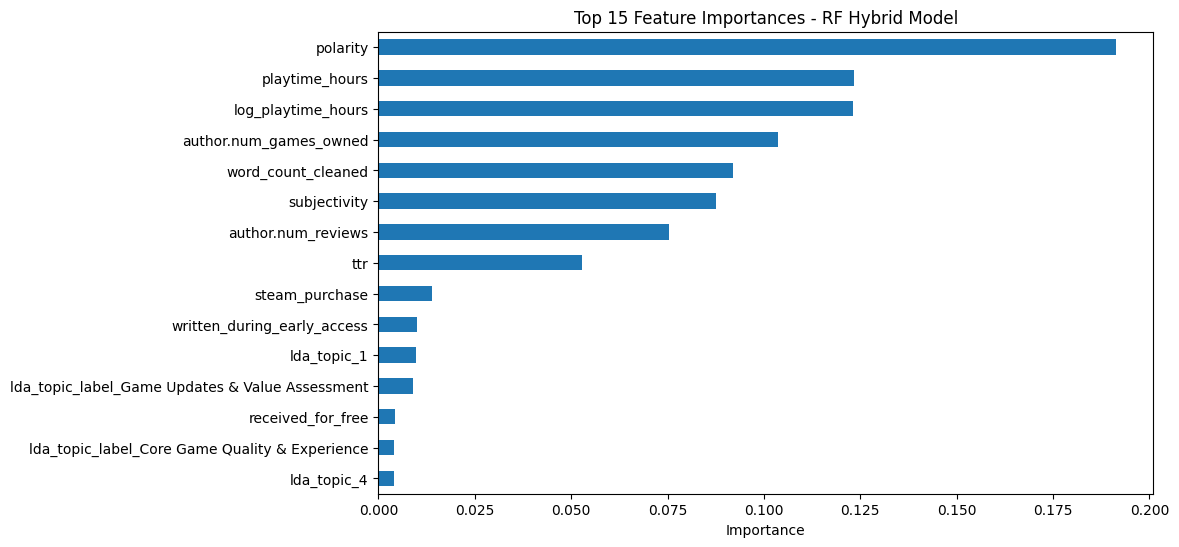

In [48]:
plt.figure(figsize=(10, 6))
rf_hybrid_importance.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Feature Importances - RF Hybrid Model")
plt.xlabel("Importance")
plt.show()

Separate Behavioral and Text Feature Contributions:

In addition to the overall feature-importance ranking, I separate the most important variables into:
- top behavioral features
- top text features

This makes the interpretation easier and helps show whether both branches are contributing useful signal to the final hybrid model rather than one branch dominating completely.

In [49]:
behavioral_importance = rf_hybrid_importance[
    rf_hybrid_importance.index.isin(X_behavioral.columns)
].sort_values(ascending=False)

text_importance = rf_hybrid_importance[
    ~rf_hybrid_importance.index.isin(X_behavioral.columns)
].sort_values(ascending=False)

print("Top behavioral features:")
print(behavioral_importance.head(10))

print("\nTop text features:")
print(text_importance.head(10))

Top behavioral features:
playtime_hours                 0.123451
log_playtime_hours             0.123151
author.num_games_owned         0.103579
author.num_reviews             0.075371
steam_purchase                 0.013886
written_during_early_access    0.010114
received_for_free              0.004258
dtype: float64

Top text features:
polarity                                           0.191432
word_count_cleaned                                 0.092080
subjectivity                                       0.087694
ttr                                                0.052853
lda_topic_1                                        0.009692
lda_topic_label_Game Updates & Value Assessment    0.008961
lda_topic_label_Core Game Quality & Experience     0.004175
lda_topic_4                                        0.004010
nmf_topic_label_Sandbox & Souls-like Games         0.003988
nmf_topic_3                                        0.003960
dtype: float64


Confusion Matrix for the Best Hybrid Model:

To complement the metric-based evaluation, I visualize the confusion matrix of the best-performing hybrid model. This provides a direct view of:
- correct positive predictions
- correct negative predictions
- false positives
- false negatives

The confusion matrix helps me understand the model’s strengths and weaknesses more concretely, especially under class imbalance.

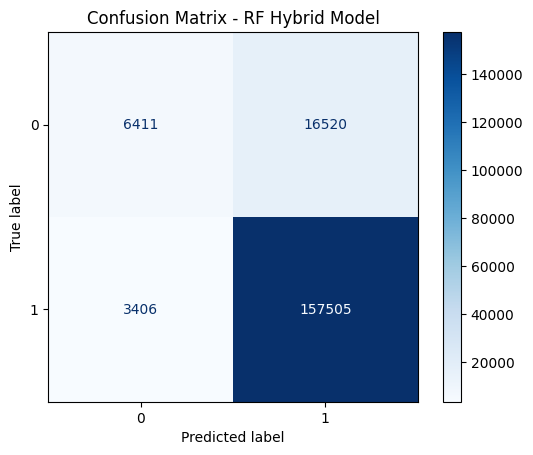

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_combined.predict(Xc_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - RF Hybrid Model")
plt.show()

Final Model Comparison Summary:

This final summary table brings together the complete comparison across all trained models. From these results, I can identify the strongest-performing approach and determine whether integrating behavioral and text features improves prediction compared with using either branch alone.

In [51]:
summary_table = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    summary_table[col] = summary_table[col].round(4)

print("Final model comparison:")
summary_table

Final model comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,RF - Hybrid,0.8916,0.9051,0.9788,0.9405,0.846275
1,AdaBoost - Hybrid,0.8870,0.8965,0.9847,0.9385,0.835932
2,AdaBoost - Text,0.8831,0.8913,0.9867,0.9366,0.820852
3,LR - Hybrid,0.8782,0.8870,0.9866,0.9341,0.814206
4,RF - Text,0.8802,0.9035,0.9663,0.9339,0.813148
5,AdaBoost - Behavioral,0.8753,0.8766,0.9980,0.9334,0.633070
6,LR - Behavioral,0.8750,0.8753,0.9996,0.9333,0.569264
7,LR - Text,0.8760,0.8843,0.9876,0.9331,0.807395
8,RF - Behavioral,0.8627,0.8803,0.9758,0.9256,0.587829


 ROC Curve Comparison for the Hybrid Models:

To complement the summary metrics, I also plot the ROC curves of the three hybrid models:
- Logistic Regression Hybrid
- Random Forest Hybrid
- AdaBoost Hybrid

This gives a visual comparison of how well each model separates the two classes across different decision thresholds. The closer the curve is to the upper-left corner, the better the model is at distinguishing recommended from non-recommended reviews.

Including the ROC curves makes the evaluation more complete and keeps this notebook consistent with the earlier modeling notebooks, where ROC-AUC was also used as an important comparison metric.

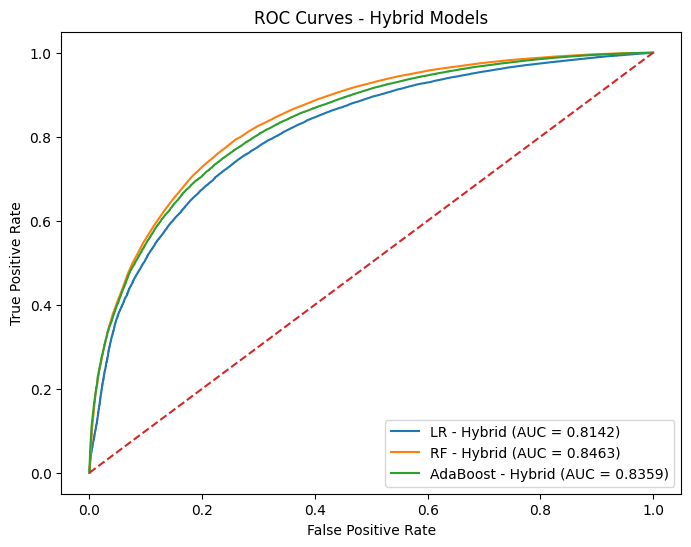

In [52]:
from sklearn.metrics import roc_curve, auc

models_for_roc = {
    'LR - Hybrid': (lr_combined, Xc_test_scaled),
    'RF - Hybrid': (rf_combined, Xc_test),
    'AdaBoost - Hybrid': (ada_combined, Xc_test_scaled)
}

plt.figure(figsize=(8, 6))

for name, (model, X_data) in models_for_roc.items():
    y_prob = model.predict_proba(X_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Hybrid Models")
plt.legend()
plt.show()

Final Conclusion:

The final hybrid experiment shows that combining behavioral and text-derived features improves review-level recommendation prediction. Among all tested models, the Random Forest Hybrid model performed best overall, outperforming both the behavioral-only and text-only alternatives.

This supports the main idea of the notebook: the two branches capture complementary information, and integrating them produces a stronger predictive model than using either branch alone.

More specifically:
- behavioral features contributed review context such as playtime and reviewer history
- text features contributed sentiment, review richness, and topical information
- the hybrid model benefited from both at the same time

Overall, this notebook demonstrates that the final unified model is more informative and more effective than the separate branch models, which makes the hybrid approach the strongest final modeling choice for this project.